# 📊 Phân Tích Khám Phá Dữ Liệu (EDA) - Ames Housing Dataset
## Khám Phá 5 Khía Cạnh Cốt Lõi & Thiết Lập Nền Tảng Tiền Xử Lý Dữ Liệu

> **Mục tiêu Dự án**: Thực hiện quy trình EDA (Exploratory Data Analysis) toàn diện trên bộ dữ liệu **Ames Housing Dataset** (1,460 mẫu train, 1,459 mẫu test, 79 đặc trưng độc lập) nhằm tìm ra quy luật dữ liệu, đặc tính phân phối, mức độ tương quan, giá trị thiếu và các điểm dị biệt (outliers), phục vụ trực tiếp cho quá trình xây dựng các mô hình Machine Learning hồi quy định giá nhà.

---

### 📑 Danh Mục 5 Khía Cạnh Phân Tích:
1. **[Tính Chất & Cấu Trúc Dữ Liệu](#1.-Tính-Chất-&-Cấu-Trúc-Dữ-Liệu)**: Kích thước, kiểu dữ liệu, tỷ lệ biến định lượng/định tính, kiểm tra trùng lặp.
2. **[Phân Tích Đơn Biến Biến Mục Tiêu SalePrice](#2.-Phân-Tích-Đơn-Biến-Biến-Mục-Tiêu-SalePrice)**: Thống kê mô tả, độ lệch (Skewness), độ nhọn (Kurtosis) & phép biến đổi $\ln(1 + \text{SalePrice})$.
3. **[Phân Tích Đa Biến & Đa Cộng Tuyến](#3.-Phân-Tích-Đa-Biến-&-Đa-Cộng-Tuyến)**: Hệ số tương quan Pearson, đa cộng tuyến nghiêm trọng ($|r| > 0.75$), quan hệ với Chất lượng (`OverallQual`), Diện tích (`GrLivArea`) và Khu vực (`Neighborhood`).
4. **[Khám Phá Giá Trị Thiếu & Mẫu Bất Thường](#4.-Khám-Phá-Giá-Trị-Thiếu-&-Mẫu-Bất-Thường)**: Phân biệt Missing Cấu trúc (Domain NaN) vs Missing Ngẫu nhiên, phát hiện dữ liệu mâu thuẫn.
5. **[Xác Định & Phân Loại Điểm Ngoại Lệ](#5.-Xác-Định-&-Phân-Loại-Điểm-Ngoại-Lệ)**: Outlier kinh điển theo tác giả Dean De Cock, kiểm tra Z-Score và phân vị IQR.
6. **[Bảng Tổng Hợp Khuyến Nghị Tiền Xử Lý](#6.-Bảng-Tổng-Hợp-Khuyến-Nghị-Tiền-Xử-Lý)**: Định hướng giải pháp cho pipeline huấn luyện mô hình.

---
## ⚙️ 0. Thiết Lập Môi Trường & Thư Viện

Chúng ta sử dụng các thư viện chuẩn mực trong Data Science:
- **`pandas` & `numpy`**: Xử lý, thao tác cấu trúc bảng và tính toán số học.
- **`matplotlib` & `seaborn`**: Trực quan hóa dữ liệu thống kê độ phân giải cao.
- **`scipy.stats`**: Tính toán các kiểm định thống kê, độ lệch, độ nhọn và biểu đồ xác suất Q-Q Plot.

In [1]:
import os
import sys
import io
import warnings
from typing import cast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Đảm bảo UTF-8 encoding trên hệ thống Windows
if isinstance(sys.stdout, io.TextIOWrapper):
    sys.stdout.reconfigure(encoding='utf-8')
if isinstance(sys.stderr, io.TextIOWrapper):
    sys.stderr.reconfigure(encoding='utf-8')

warnings.filterwarnings('ignore')
%matplotlib inline

# Cấu hình phong cách biểu đồ trực quan
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 10
plt.rcParams['figure.dpi'] = 150

PLOTS_DIR = 'plots'
os.makedirs(PLOTS_DIR, exist_ok=True)

print("✅ Đã thiết lập thành công môi trường thư viện và cấu hình hiển thị!")

✅ Đã thiết lập thành công môi trường thư viện và cấu hình hiển thị!


---
## 🔍 1. Tính Chất & Cấu Trúc Dữ Liệu (Data Properties & Shapes)

Trong bước đầu tiên, ta đọc dữ liệu từ hai tập tin `train.csv` và `test.csv`, kiểm tra kích thước mẫu, kiểm tra tính toàn vẹn (trùng lặp) và phân loại các biến định lượng (numerical) thành liên tục (continuous) và rời rạc (discrete).

In [2]:
# Đường dẫn tới bộ dữ liệu
train_path = os.path.join('house-prices-advanced-regression-techniques', 'train.csv')
test_path = os.path.join('house-prices-advanced-regression-techniques', 'test.csv')

train = pd.read_csv(train_path)
test = pd.read_csv(test_path)

print("=" * 70)
print(f"📊 KÍCH THƯỚC DỮ LIỆU:")
print(f"  • Tập Huấn luyện (Train set): {train.shape[0]:,} dòng × {train.shape[1]} cột (bao gồm Id & SalePrice)")
print(f"  • Tập Kiểm thử   (Test set) : {test.shape[0]:,} dòng × {test.shape[1]} cột (bao gồm Id)")
print(f"  • Số dòng trùng lặp (Duplicates): {train.duplicated().sum()}")
print("=" * 70)

# Phân loại biến
num_cols = train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = train.select_dtypes(include=['object', 'string']).columns.tolist()

# Biến số: Rời rạc (ít hơn 25 giá trị khác nhau) vs Liên tục
discrete_cols = [c for c in num_cols if train[c].nunique() < 25 and c not in ['Id']]
continuous_cols = [c for c in num_cols if train[c].nunique() >= 25 and c not in ['Id', 'SalePrice']]

print(f"📈 PHÂN LOẠI ĐẶC TRƯNG:")
print(f"  • Biến Định lượng (Numerical) : {len(num_cols)} cột")
print(f"      - Liên tục (Continuous)   : {len(continuous_cols)} cột (diện tích các tầng, sân vườn, giá...)")
print(f"      - Rời rạc (Discrete)      : {len(discrete_cols)} cột (năm xây, số phòng, số phòng tắm...)")
print(f"  • Biến Định tính  (Categorical): {len(cat_cols)} cột (vị trí khu vực, kiểu nhà, chất liệu...)")

# Hiển thị 5 dòng đầu tiên của tập train
train.head(5)

📊 KÍCH THƯỚC DỮ LIỆU:
  • Tập Huấn luyện (Train set): 1,460 dòng × 81 cột (bao gồm Id & SalePrice)
  • Tập Kiểm thử   (Test set) : 1,459 dòng × 80 cột (bao gồm Id)
  • Số dòng trùng lặp (Duplicates): 0
📈 PHÂN LOẠI ĐẶC TRƯNG:
  • Biến Định lượng (Numerical) : 38 cột
      - Liên tục (Continuous)   : 18 cột (diện tích các tầng, sân vườn, giá...)
      - Rời rạc (Discrete)      : 18 cột (năm xây, số phòng, số phòng tắm...)
  • Biến Định tính  (Categorical): 43 cột (vị trí khu vực, kiểu nhà, chất liệu...)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


---
## 🎯 2. Phân Tích Đơn Biến Biến Mục Tiêu `SalePrice` (Univariate Analysis)

Biến mục tiêu `SalePrice` là giá bán thực tế của bất động sản. Các mô hình hồi quy tuyến tính và gradient boosting hoạt động hiệu quả nhất khi phần dư (residuals) tuân theo phân phối chuẩn với phương sai không đổi (homoscedasticity).

### Phân tích đặc tính thống kê:
- **Độ lệch (Skewness)**: Đo lường tính bất đối xứng. Giá trị $>0$ thể hiện phân phối lệch phải (đuôi dài về phía giá cao).
- **Độ nhọn (Kurtosis)**: Đo lường độ dày của đuôi. Giá trị $>3$ thể hiện phân phối nhọn và nhiều giá trị cực biên (heavy-tailed).
- **Phép biến đổi $y = \ln(1 + \text{SalePrice})$**: Chuẩn hóa phân phối về dạng Gauss đối xứng.

In [3]:
sp = train['SalePrice']
sp_skew = sp.skew()
sp_kurt = sp.kurt()
log_sp = np.log1p(sp)
log_sp_skew = pd.Series(log_sp).skew()
log_sp_kurt = pd.Series(log_sp).kurt()

q1 = sp.quantile(0.25)
q3 = sp.quantile(0.75)
iqr = q3 - q1

print("=" * 70)
print("📊 CÁC CHỈ SỐ THỐNG KÊ BIẾN MỤC TIÊU SALEPRICE:")
print(f"  • Mean (Trung bình)        : ${sp.mean():,.2f}")
print(f"  • Median (Trung vị)        : ${sp.median():,.2f}")
print(f"  • Std (Độ lệch chuẩn)      : ${sp.std():,.2f}")
print(f"  • Tứ phân vị Q1 (25%)      : ${q1:,.2f}")
print(f"  • Tứ phân vị Q3 (75%)      : ${q3:,.2f}")
print(f"  • Khoảng trải giữa (IQR)   : ${iqr:,.2f}")
print("-" * 70)
print(f"  • Độ lệch Gốc (Skewness)   : {sp_skew:.3f} (Lệch phải mạnh / Positive Skew)")
print(f"  • Độ nhọn Gốc (Kurtosis)   : {sp_kurt:.3f} (Leptokurtic, đuôi rất dày)")
print(f"  • Sau Log-transform (log1p): Skewness = {log_sp_skew:.3f} (≈ 0), Kurtosis = {log_sp_kurt:.3f}")
print("=" * 70)

📊 CÁC CHỈ SỐ THỐNG KÊ BIẾN MỤC TIÊU SALEPRICE:
  • Mean (Trung bình)        : $180,921.20
  • Median (Trung vị)        : $163,000.00
  • Std (Độ lệch chuẩn)      : $79,442.50
  • Tứ phân vị Q1 (25%)      : $129,975.00
  • Tứ phân vị Q3 (75%)      : $214,000.00
  • Khoảng trải giữa (IQR)   : $84,025.00
----------------------------------------------------------------------
  • Độ lệch Gốc (Skewness)   : 1.883 (Lệch phải mạnh / Positive Skew)
  • Độ nhọn Gốc (Kurtosis)   : 6.536 (Leptokurtic, đuôi rất dày)
  • Sau Log-transform (log1p): Skewness = 0.121 (≈ 0), Kurtosis = 0.810


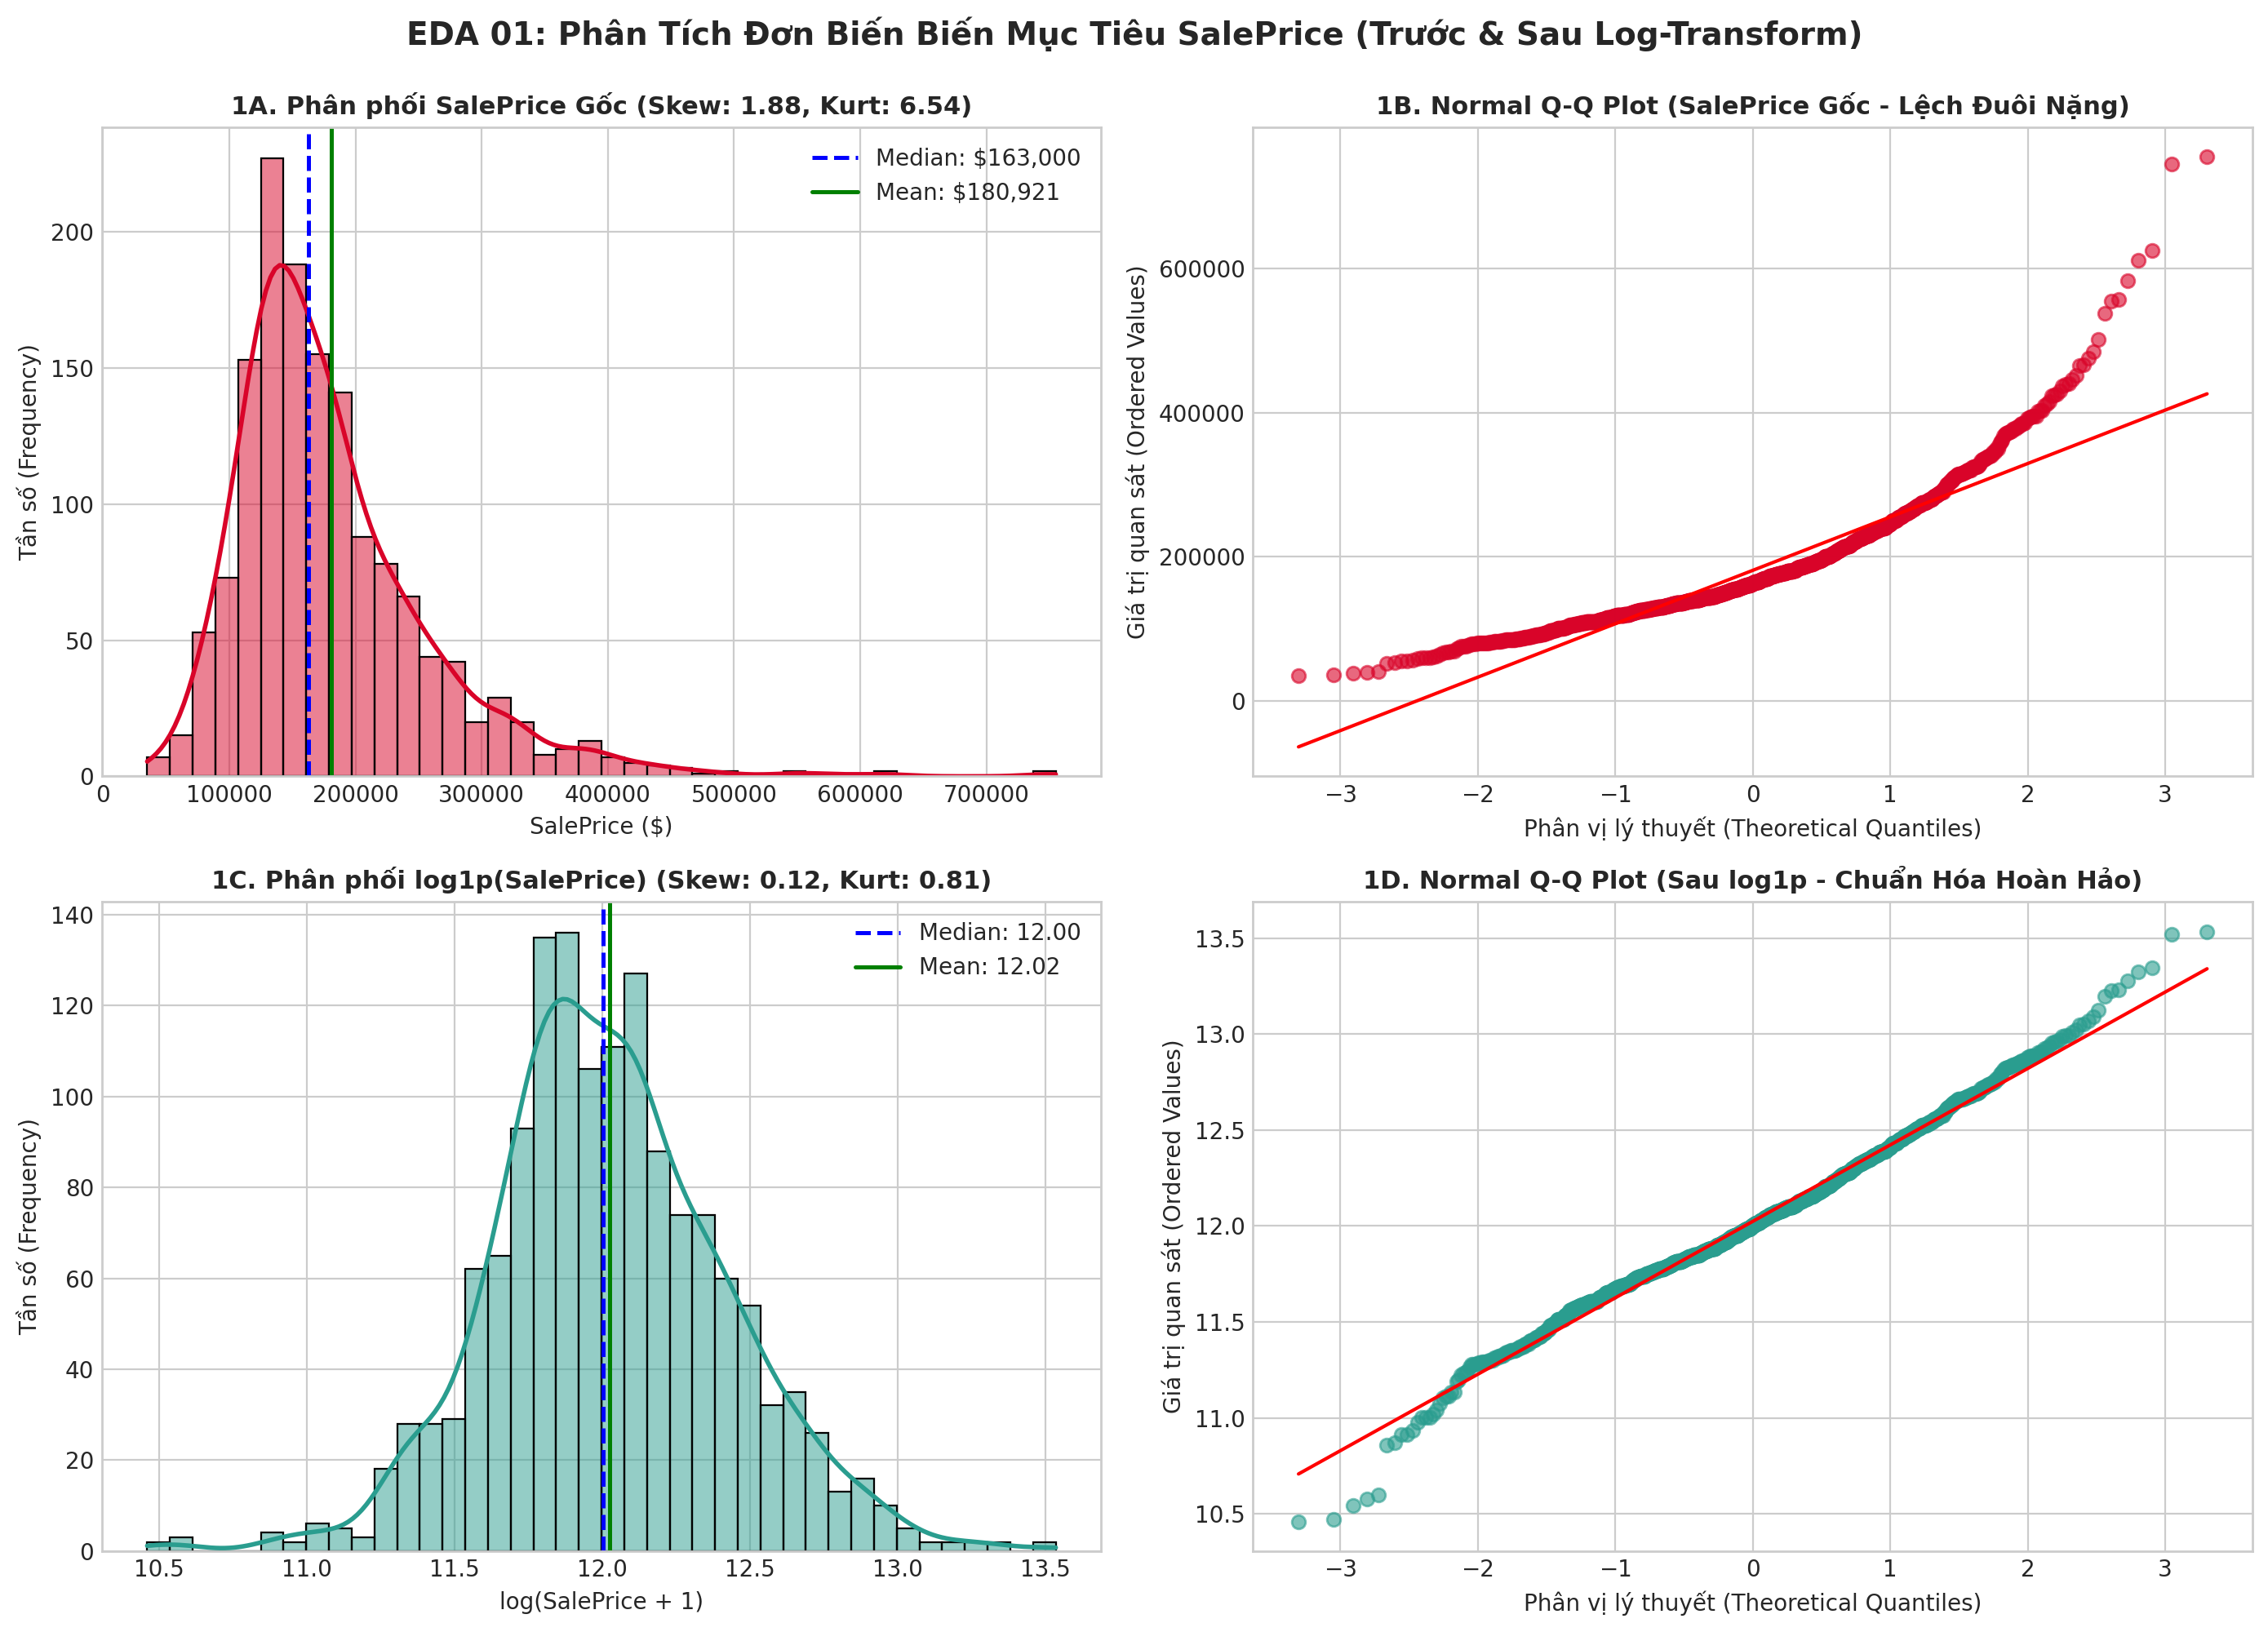

💾 Biểu đồ đã được lưu tại: plots\eda_01_target_distribution.png


In [4]:
# Vẽ Biểu đồ 1: Phân tích đơn biến biến mục tiêu (Trước & Sau biến đổi Log)
fig, axes = plt.subplots(2, 2, figsize=(14, 10), dpi=200)

# 1A: Phân phối SalePrice gốc
sns.histplot(sp.to_numpy(), kde=True, ax=axes[0, 0], color='#d90429', bins=40, line_kws={'lw': 2})
axes[0, 0].set_title(f'1A. Phân phối SalePrice Gốc (Skew: {sp_skew:.2f}, Kurt: {sp_kurt:.2f})', fontweight='bold', fontsize=11)
axes[0, 0].set_xlabel('SalePrice ($)', fontsize=10)
axes[0, 0].set_ylabel('Tần số (Frequency)', fontsize=10)
axes[0, 0].axvline(sp.median(), color='blue', linestyle='--', lw=1.8, label=f'Median: ${sp.median():,.0f}')
axes[0, 0].axvline(sp.mean(), color='green', linestyle='-', lw=1.8, label=f'Mean: ${sp.mean():,.0f}')
axes[0, 0].legend()

# 1B: Q-Q Plot SalePrice gốc
stats.probplot(sp, plot=axes[0, 1])
axes[0, 1].get_lines()[0].set_color('#d90429')
axes[0, 1].get_lines()[0].set_alpha(0.6)
axes[0, 1].set_title('1B. Normal Q-Q Plot (SalePrice Gốc - Lệch Đuôi Nặng)', fontweight='bold', fontsize=11)
axes[0, 1].set_xlabel('Phân vị lý thuyết (Theoretical Quantiles)', fontsize=10)
axes[0, 1].set_ylabel('Giá trị quan sát (Ordered Values)', fontsize=10)

# 1C: Phân phối log1p(SalePrice)
sns.histplot(log_sp, kde=True, ax=axes[1, 0], color='#2a9d8f', bins=40, line_kws={'lw': 2})
axes[1, 0].set_title(f'1C. Phân phối log1p(SalePrice) (Skew: {log_sp_skew:.2f}, Kurt: {log_sp_kurt:.2f})', fontweight='bold', fontsize=11)
axes[1, 0].set_xlabel('log(SalePrice + 1)', fontsize=10)
axes[1, 0].set_ylabel('Tần số (Frequency)', fontsize=10)
axes[1, 0].axvline(np.median(log_sp), color='blue', linestyle='--', lw=1.8, label=f'Median: {np.median(log_sp):.2f}')
axes[1, 0].axvline(log_sp.mean(), color='green', linestyle='-', lw=1.8, label=f'Mean: {log_sp.mean():.2f}')
axes[1, 0].legend()

# 1D: Q-Q Plot sau log1p
stats.probplot(log_sp, plot=axes[1, 1])
axes[1, 1].get_lines()[0].set_color('#2a9d8f')
axes[1, 1].get_lines()[0].set_alpha(0.6)
axes[1, 1].set_title('1D. Normal Q-Q Plot (Sau log1p - Chuẩn Hóa Hoàn Hảo)', fontweight='bold', fontsize=11)
axes[1, 1].set_xlabel('Phân vị lý thuyết (Theoretical Quantiles)', fontsize=10)
axes[1, 1].set_ylabel('Giá trị quan sát (Ordered Values)', fontsize=10)

fig.suptitle('EDA 01: Phân Tích Đơn Biến Biến Mục Tiêu SalePrice (Trước & Sau Log-Transform)', fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()

plot1_path = os.path.join(PLOTS_DIR, 'eda_01_target_distribution.png')
plt.savefig(plot1_path, bbox_inches='tight')
plt.show()
print(f"💾 Biểu đồ đã được lưu tại: {plot1_path}")

---
## 🔗 3. Phân Tích Đa Biến & Đa Cộng Tuyến (Multivariate Analysis & Collinearity)

Mục tiêu phần này là xác định các đặc trưng có ảnh hưởng mạnh nhất đến `SalePrice`, đồng thời phát hiện các cặp biến giải thích có tương quan nội bộ quá cao ($|r| > 0.75$), gây ra hiện tượng **Đa cộng tuyến (Multicollinearity)**.

In [5]:
num_features = [c for c in num_cols if c not in ['Id', 'SalePrice']]
corr_series = train[num_features + ['SalePrice']].corr()['SalePrice'].sort_values(ascending=False)
top15_features = corr_series.iloc[1:16].index.tolist()

print("=" * 70)
print("🏆 TOP 10 ĐẶC TRƯNG CÓ TƯƠNG QUAN TUYẾN TÍNH MẠNH NHẤT VỚI SALEPRICE:")
print("=" * 70)
for rank, (feat, r_val) in enumerate(corr_series.iloc[1:11].items(), 1):
    print(f"  {rank:2d}. {feat:<18}: r = {r_val:+.4f}")

# Kiểm tra hiện tượng đa cộng tuyến giữa các biến độc lập
corr_matrix = train[num_features].corr()
print("\n" + "=" * 70)
print("⚠️ CÁC CẶP BIẾN ĐỘC LẬP CÓ ĐA CỘNG TUYẾN CAO (|r| > 0.75):")
print("=" * 70)
seen = set()
for col1 in num_features:
    for col2 in num_features:
        if col1 != col2 and (col2, col1) not in seen:
            val = cast(float, corr_matrix.loc[col1, col2])
            if abs(val) > 0.75:
                print(f"  • {col1:<16} <---> {col2:<16} : r = {val:+.4f}")
                seen.add((col1, col2))

🏆 TOP 10 ĐẶC TRƯNG CÓ TƯƠNG QUAN TUYẾN TÍNH MẠNH NHẤT VỚI SALEPRICE:
   1. OverallQual       : r = +0.7910
   2. GrLivArea         : r = +0.7086
   3. GarageCars        : r = +0.6404
   4. GarageArea        : r = +0.6234
   5. TotalBsmtSF       : r = +0.6136
   6. 1stFlrSF          : r = +0.6059
   7. FullBath          : r = +0.5607
   8. TotRmsAbvGrd      : r = +0.5337
   9. YearBuilt         : r = +0.5229
  10. YearRemodAdd      : r = +0.5071

⚠️ CÁC CẶP BIẾN ĐỘC LẬP CÓ ĐA CỘNG TUYẾN CAO (|r| > 0.75):
  • YearBuilt        <---> GarageYrBlt      : r = +0.8257
  • TotalBsmtSF      <---> 1stFlrSF         : r = +0.8195
  • GrLivArea        <---> TotRmsAbvGrd     : r = +0.8255
  • GarageCars       <---> GarageArea       : r = +0.8825


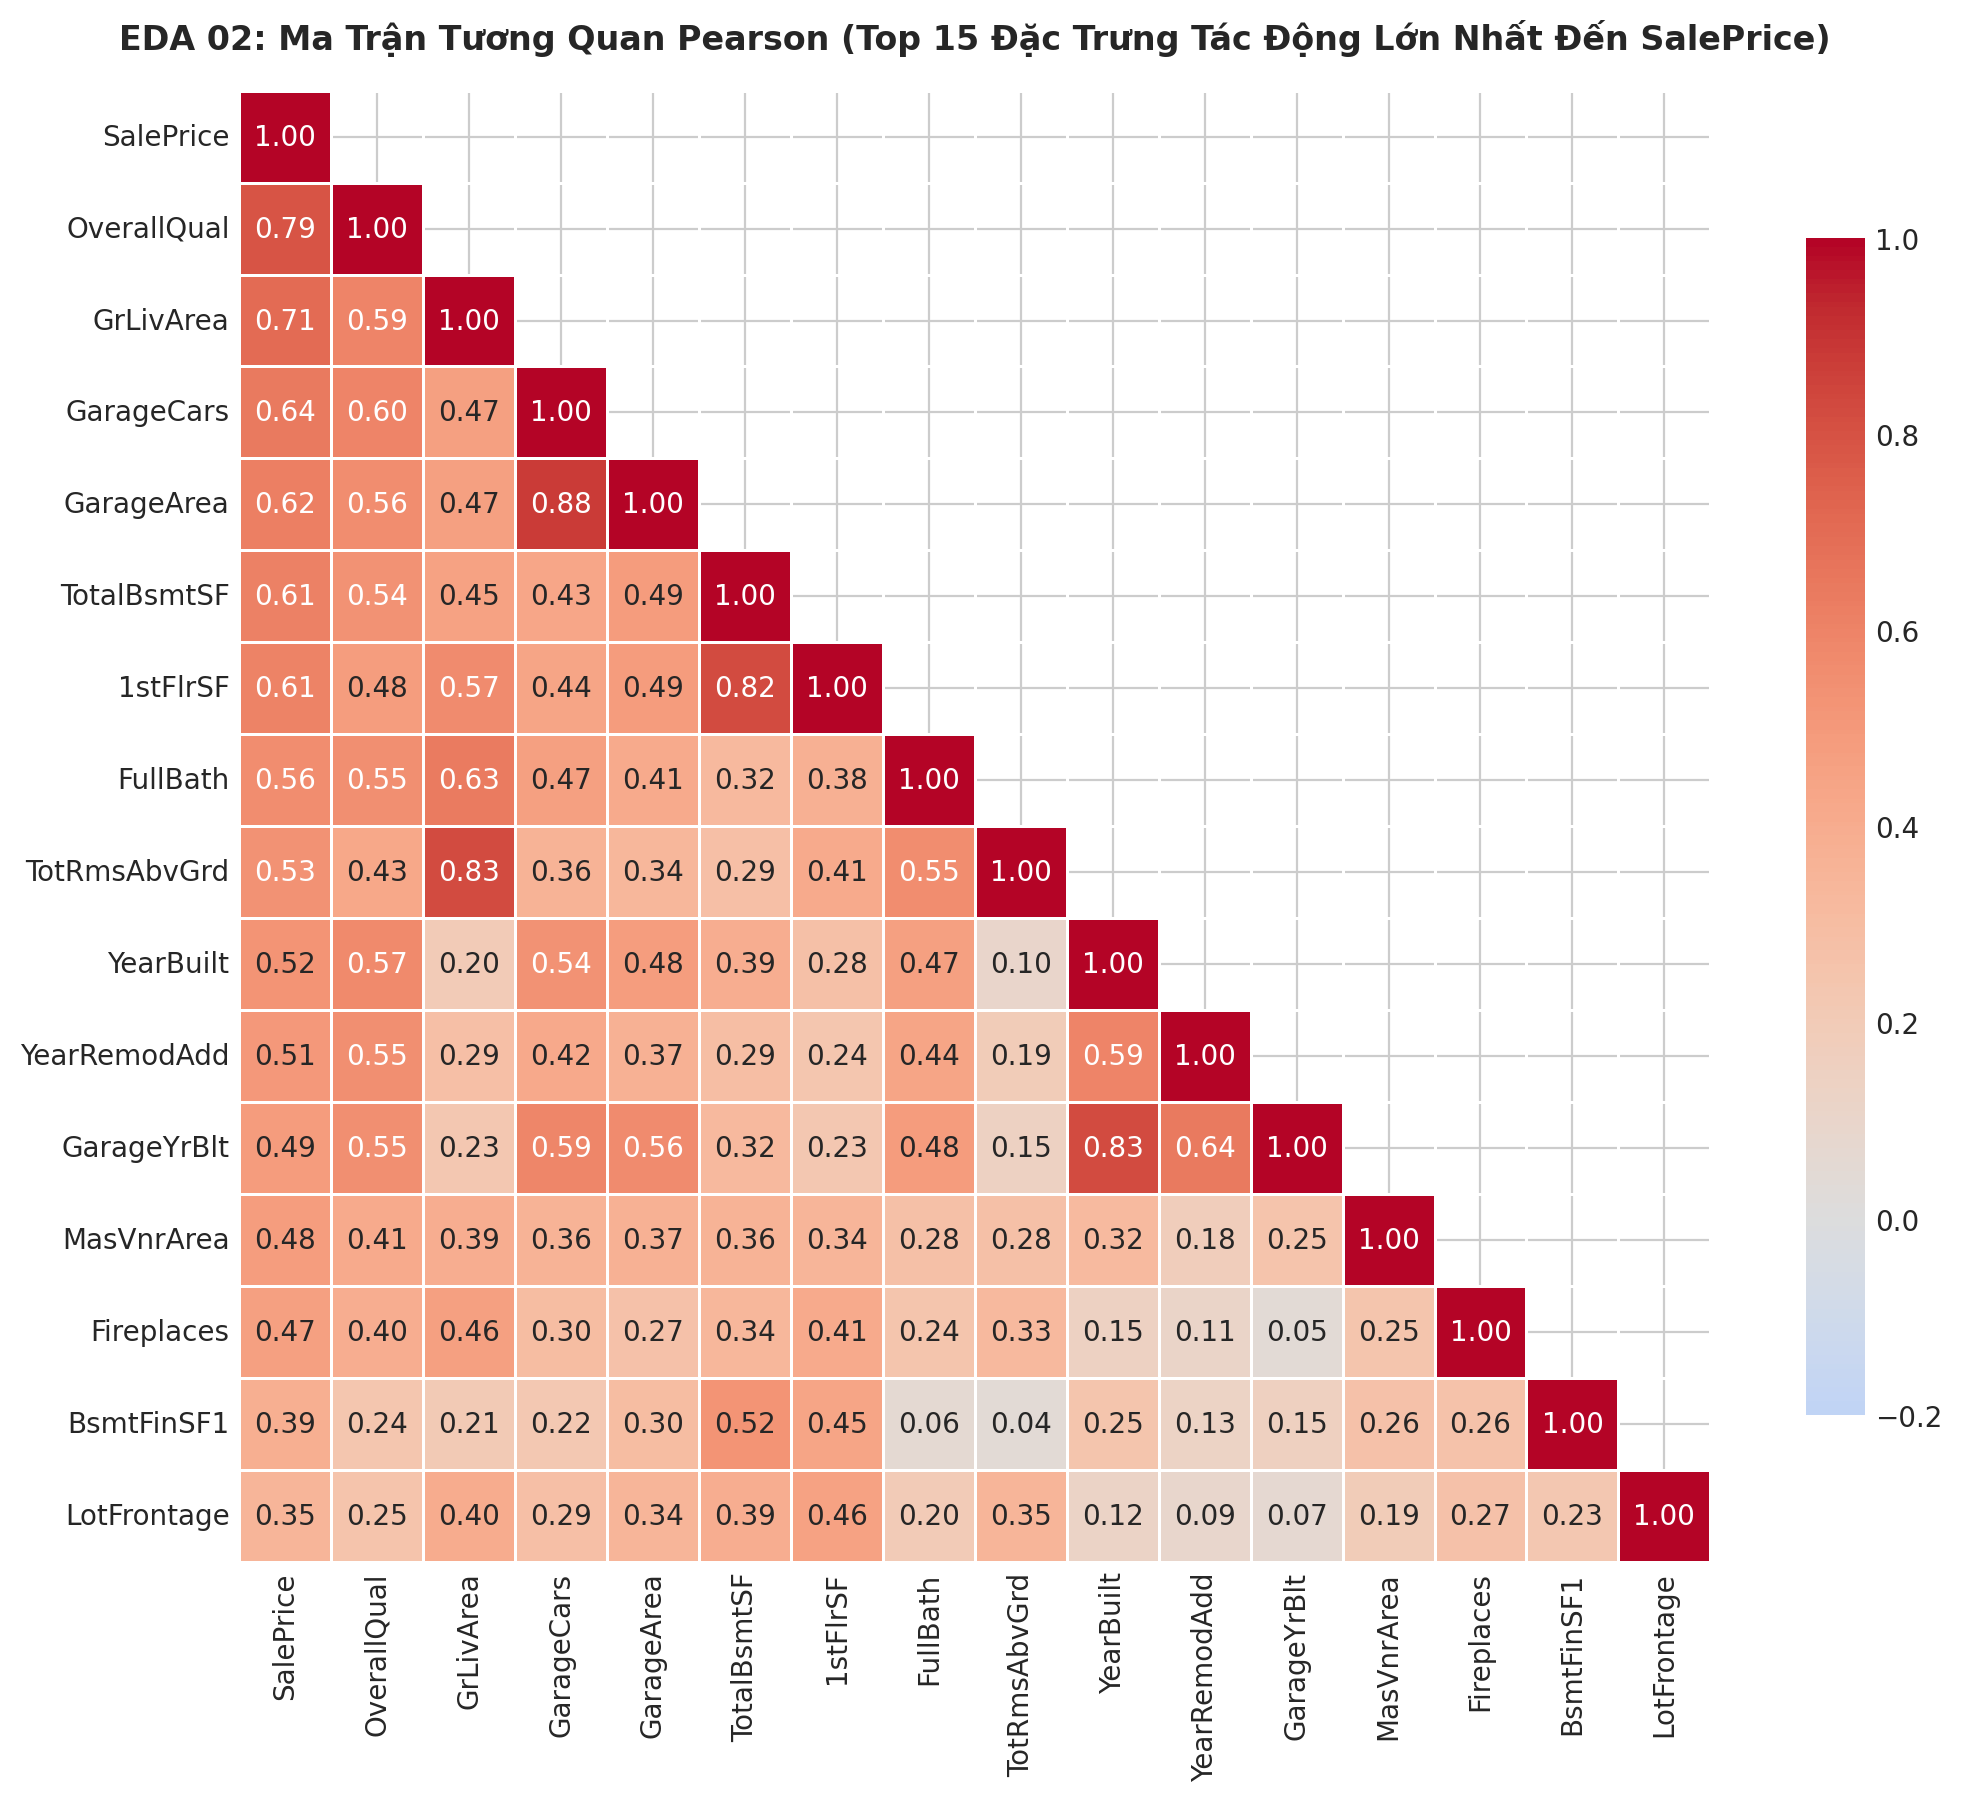

💾 Biểu đồ đã được lưu tại: plots\eda_02_correlation_heatmap.png


In [6]:
# Vẽ Biểu đồ 2: Heatmap tương quan Top 15 đặc trưng mạnh nhất
fig, ax = plt.subplots(figsize=(11, 9), dpi=200)
top15_with_target = ['SalePrice'] + top15_features
heatmap_data = train[top15_with_target].corr()
mask = np.triu(np.ones_like(heatmap_data, dtype=bool), k=1)

sns.heatmap(heatmap_data, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-0.2, vmax=1.0, square=True, linewidths=0.5, 
            cbar_kws={'shrink': 0.8}, ax=ax)
ax.set_title('EDA 02: Ma Trận Tương Quan Pearson (Top 15 Đặc Trưng Tác Động Lớn Nhất Đến SalePrice)', 
             fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()

plot2_path = os.path.join(PLOTS_DIR, 'eda_02_correlation_heatmap.png')
plt.savefig(plot2_path, bbox_inches='tight')
plt.show()
print(f"💾 Biểu đồ đã được lưu tại: {plot2_path}")

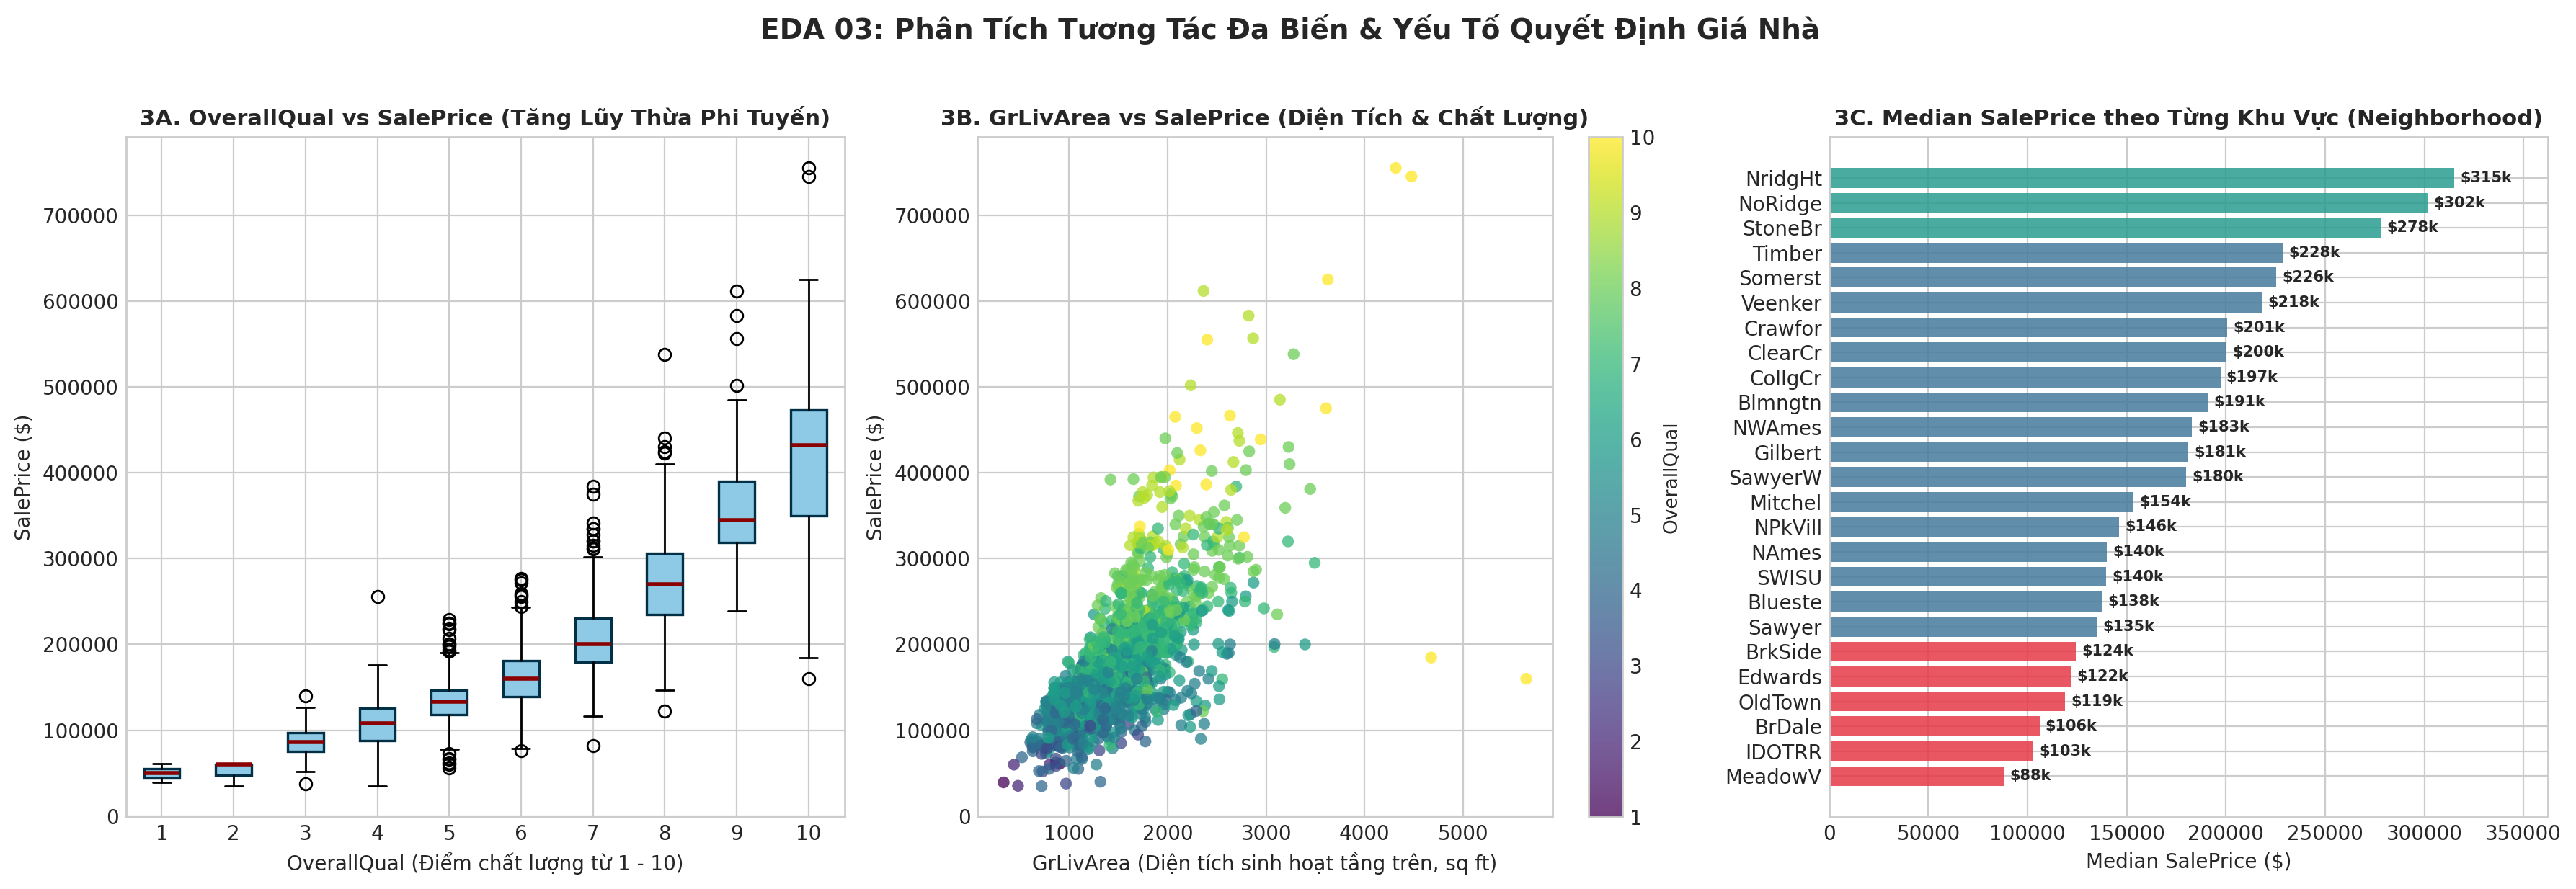

💾 Biểu đồ đã được lưu tại: plots\eda_03_multivariate_relationships.png


In [7]:
# Vẽ Biểu đồ 3: Mối quan hệ đa biến (OverallQual, GrLivArea, Neighborhood vs SalePrice)
fig, axes = plt.subplots(1, 3, figsize=(18, 6), dpi=200)

# 3A: OverallQual vs SalePrice Boxplot
qual_order = sorted(train['OverallQual'].unique())
qual_box_data = [train[train['OverallQual'] == q]['SalePrice'].values for q in qual_order]
axes[0].boxplot(qual_box_data, tick_labels=qual_order, patch_artist=True,
                boxprops=dict(facecolor='#8ecae6', edgecolor='#023047', lw=1.2),
                medianprops=dict(color='darkred', lw=2))
axes[0].set_title('3A. OverallQual vs SalePrice (Tăng Lũy Thừa Phi Tuyến)', fontweight='bold', fontsize=11)
axes[0].set_xlabel('OverallQual (Điểm chất lượng từ 1 - 10)', fontsize=10)
axes[0].set_ylabel('SalePrice ($)', fontsize=10)

# 3B: GrLivArea vs SalePrice Scatter phân màu theo OverallQual
scatter = axes[1].scatter(train['GrLivArea'], train['SalePrice'], c=train['OverallQual'],
                          cmap='viridis', alpha=0.75, s=35, edgecolors='none')
cbar = plt.colorbar(scatter, ax=axes[1])
cbar.set_label('OverallQual', fontsize=9.5)
axes[1].set_title('3B. GrLivArea vs SalePrice (Diện Tích & Chất Lượng)', fontweight='bold', fontsize=11)
axes[1].set_xlabel('GrLivArea (Diện tích sinh hoạt tầng trên, sq ft)', fontsize=10)
axes[1].set_ylabel('SalePrice ($)', fontsize=10)

# 3C: Neighborhood vs Median SalePrice (Top & Bottom)
neigh_median = pd.Series(train.groupby('Neighborhood')['SalePrice'].median()).sort_values()
colors = ['#e63946' if x < 130000 else '#2a9d8f' if x > 250000 else '#457b9d' for x in neigh_median.values]
axes[2].barh(neigh_median.index, neigh_median.values, color=colors, alpha=0.85)
axes[2].set_title('3C. Median SalePrice theo Từng Khu Vực (Neighborhood)', fontweight='bold', fontsize=11)
axes[2].set_xlabel('Median SalePrice ($)', fontsize=10)
axes[2].set_xlim(0, max(neigh_median.values) * 1.15)
for i, val in enumerate(neigh_median.values):
    axes[2].text(val + 3000, i, f"${val/1000:.0f}k", va='center', fontsize=7.5, fontweight='bold')

fig.suptitle('EDA 03: Phân Tích Tương Tác Đa Biến & Yếu Tố Quyết Định Giá Nhà', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()

plot3_path = os.path.join(PLOTS_DIR, 'eda_03_multivariate_relationships.png')
plt.savefig(plot3_path, bbox_inches='tight')
plt.show()
print(f"💾 Biểu đồ đã được lưu tại: {plot3_path}")

---
## 🧩 4. Khám Phá Giá Trị Thiếu & Mẫu Bất Thường (Missing Values & Inconsistencies)

Một trong những sai lầm phổ biến nhất khi xử lý Ames Housing là điền tùy tiện `mode`/`mean` cho toàn bộ các ô `NaN`.
Thực tế trong bộ dữ liệu này, `NaN` chia làm **2 nhóm hoàn toàn khác biệt**:

1. **Nhóm Cấu trúc (Structural / Domain NaN)**:
   - Các căn nhà đơn giản là **không có tiện ích đó** (ví dụ: không có hồ bơi `PoolQC`, không có gara `GarageType`, không có hầm `BsmtQual`).
   - $\rightarrow$ **Giải pháp**: Phải điền `'None'` cho biến chuỗi và `0` cho biến diện tích/số lượng tương ứng, **tuyệt đối không xóa dòng hay điền mean**.
2. **Nhóm Ngẫu nhiên (MCAR / MAR)**:
   - Dữ liệu bị thiếu do quá trình đo đạc/thu thập (`LotFrontage`, `MasVnrType`, `Electrical`).
   - $\rightarrow$ **Giải pháp**: Cần Impute thông minh (ví dụ: `LotFrontage` phụ thuộc vào quy hoạch mặt tiền của từng phân vùng `Neighborhood`).

In [8]:
missing_train = train.isnull().sum()
missing_train = missing_train[missing_train > 0].sort_values(ascending=False)
missing_pct = (missing_train / len(train)) * 100

structural_cols = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu', 
                   'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
                   'BsmtExposure', 'BsmtFinType2', 'BsmtQual', 'BsmtCond', 'BsmtFinType1']
random_cols = ['LotFrontage', 'MasVnrType', 'MasVnrArea', 'Electrical']

print("=" * 70)
print("📋 PHÂN LOẠI CHI TIẾT CÁC CỘT CÓ GIÁ TRỊ THIẾU (MISSING VALUES):")
print("=" * 70)
print("🔴 1. NHÓM CẤU TRÚC (Domain NaN: Không có tiện ích -> Điền 'None' hoặc 0):")
for sc in structural_cols:
    if sc in missing_train:
        print(f"   • {sc:<16}: {missing_train[sc]:4d} mẫu ({missing_pct[sc]:5.2f}%)")

print("\n🟢 2. NHÓM NGẪU NHIÊN (MCAR/MAR: Cần Impute thông minh theo nhóm):")
for rc in random_cols:
    if rc in missing_train:
        print(f"   • {rc:<16}: {missing_train[rc]:4d} mẫu ({missing_pct[rc]:5.2f}%)")

# Mẫu bất thường / Mâu thuẫn logic phát hiện qua EDA
print("\n" + "=" * 70)
print("⚠️ CÁC MẪU MÂU THUẪN DỮ LIỆU CẦN ĐIỀU CHỈNH TRƯỚC KHI TRAIN:")
print("=" * 70)
inconsist_mas = train[train['MasVnrType'].isnull() & (train['MasVnrArea'] > 0)]
print(f"  • {len(inconsist_mas)} mẫu có MasVnrArea > 0 nhưng MasVnrType = NaN -> Ids: {inconsist_mas['Id'].tolist()}")

inconsist_mas2 = train[(train['MasVnrType'].notnull()) & (train['MasVnrType'] != 'None') & (train['MasVnrArea'] == 0)]
print(f"  • {len(inconsist_mas2)} mẫu có MasVnrType khác None nhưng MasVnrArea = 0 -> Ids: {inconsist_mas2['Id'].tolist()}")

test_abnormal_yr = test[test['GarageYrBlt'] > 2010]
if len(test_abnormal_yr) > 0:
    print(f"  • Test set có GarageYrBlt bất thường: Id {test_abnormal_yr.iloc[0]['Id']} có năm {test_abnormal_yr.iloc[0]['GarageYrBlt']:.0f} (YearBuilt = {test_abnormal_yr.iloc[0]['YearBuilt']}) -> Cần sửa thành 2006!")

📋 PHÂN LOẠI CHI TIẾT CÁC CỘT CÓ GIÁ TRỊ THIẾU (MISSING VALUES):
🔴 1. NHÓM CẤU TRÚC (Domain NaN: Không có tiện ích -> Điền 'None' hoặc 0):
   • PoolQC          : 1453 mẫu (99.52%)
   • MiscFeature     : 1406 mẫu (96.30%)
   • Alley           : 1369 mẫu (93.77%)
   • Fence           : 1179 mẫu (80.75%)
   • FireplaceQu     :  690 mẫu (47.26%)
   • GarageType      :   81 mẫu ( 5.55%)
   • GarageFinish    :   81 mẫu ( 5.55%)
   • GarageQual      :   81 mẫu ( 5.55%)
   • GarageCond      :   81 mẫu ( 5.55%)
   • BsmtExposure    :   38 mẫu ( 2.60%)
   • BsmtFinType2    :   38 mẫu ( 2.60%)
   • BsmtQual        :   37 mẫu ( 2.53%)
   • BsmtCond        :   37 mẫu ( 2.53%)
   • BsmtFinType1    :   37 mẫu ( 2.53%)

🟢 2. NHÓM NGẪU NHIÊN (MCAR/MAR: Cần Impute thông minh theo nhóm):
   • LotFrontage     :  259 mẫu (17.74%)
   • MasVnrType      :  872 mẫu (59.73%)
   • MasVnrArea      :    8 mẫu ( 0.55%)
   • Electrical      :    1 mẫu ( 0.07%)

⚠️ CÁC MẪU MÂU THUẪN DỮ LIỆU CẦN ĐIỀU CHỈNH TRƯỚC KHI TR

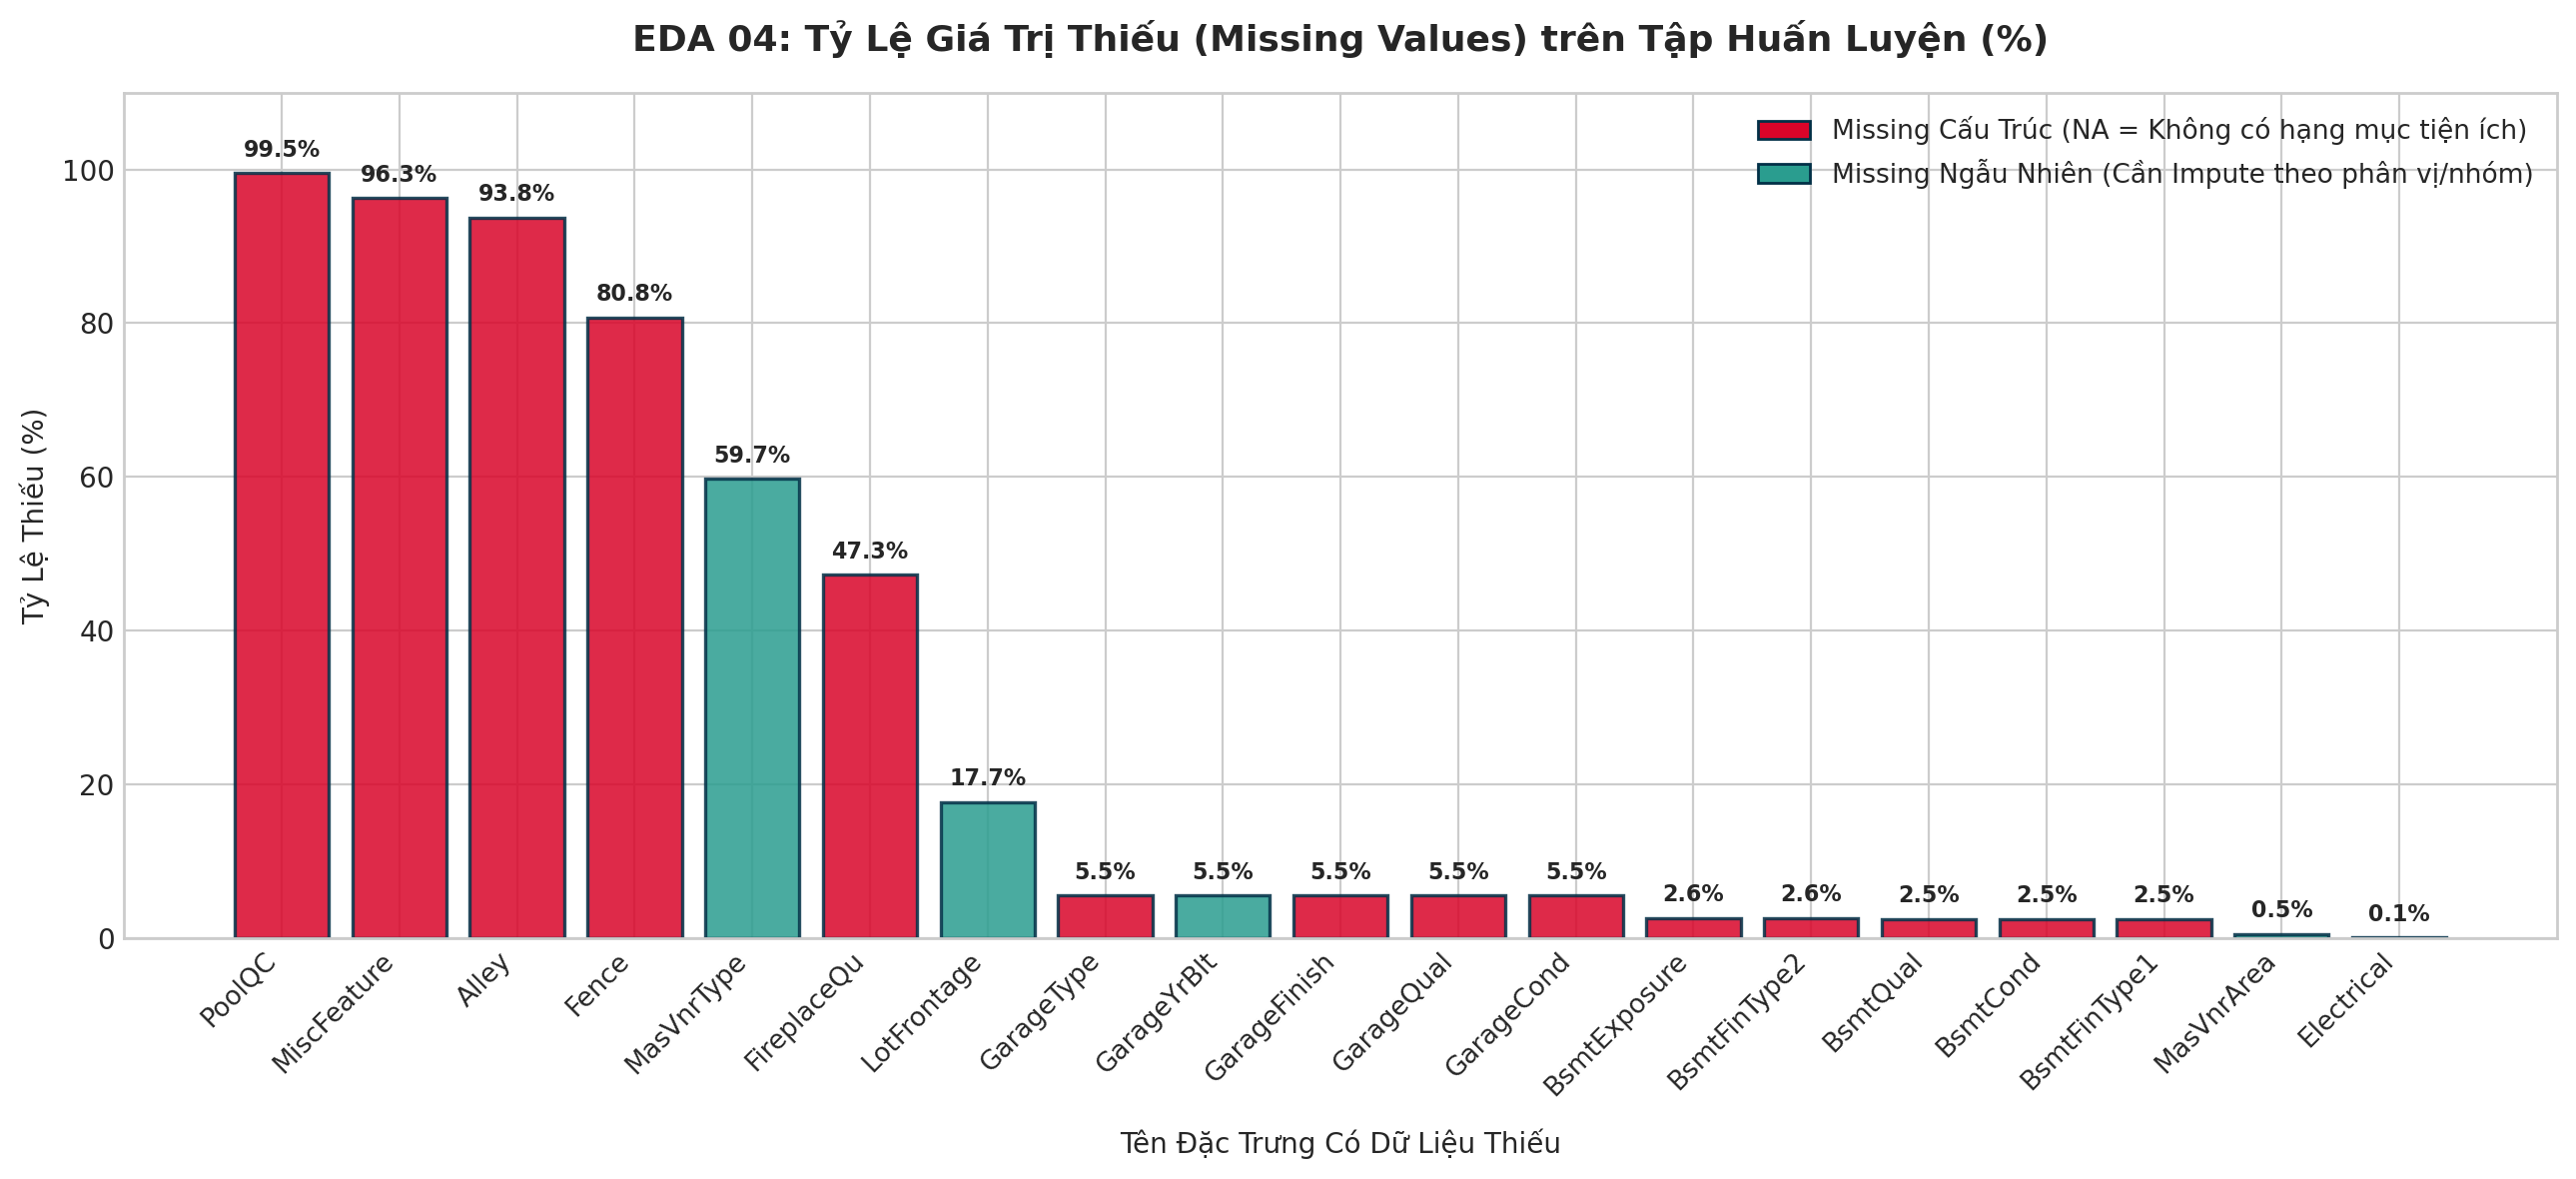

💾 Biểu đồ đã được lưu tại: plots\eda_04_missing_values.png


In [9]:
# Vẽ Biểu đồ 4: Trực quan hóa tỷ lệ phần trăm missing values
from matplotlib.patches import Patch

fig, ax = plt.subplots(figsize=(13, 6), dpi=200)
bar_colors = ['#d90429' if c in structural_cols else '#2a9d8f' for c in missing_train.index]
bars = ax.bar(missing_train.index, missing_pct.values, color=bar_colors, alpha=0.85, edgecolor='#023047', lw=1.2)

ax.set_title('EDA 04: Tỷ Lệ Giá Trị Thiếu (Missing Values) trên Tập Huấn Luyện (%)', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Tên Đặc Trưng Có Dữ Liệu Thiếu', fontsize=10, labelpad=10)
ax.set_ylabel('Tỷ Lệ Thiếu (%)', fontsize=10)
ax.set_ylim(0, 110)
plt.xticks(rotation=45, ha='right', fontsize=9.5)

# Hiển thị số liệu % lên từng cột
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h + 1.5, f"{h:.1f}%", ha='center', va='bottom', fontsize=8, fontweight='bold')

legend_elements = [
    Patch(facecolor='#d90429', edgecolor='#023047', label='Missing Cấu Trúc (NA = Không có hạng mục tiện ích)'),
    Patch(facecolor='#2a9d8f', edgecolor='#023047', label='Missing Ngẫu Nhiên (Cần Impute theo phân vị/nhóm)')
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=9.5)
plt.tight_layout()

plot4_path = os.path.join(PLOTS_DIR, 'eda_04_missing_values.png')
plt.savefig(plot4_path, bbox_inches='tight')
plt.show()
print(f"💾 Biểu đồ đã được lưu tại: {plot4_path}")

---
## 🚨 5. Xác Định & Phân Loại Điểm Ngoại Lệ (Outliers Detection)

Giáo sư **Dean De Cock** (tác giả bộ dữ liệu Ames Housing) đã chỉ rõ trong bài báo nghiên cứu:
> *"Có 5 căn nhà diện tích sinh hoạt lớn bất thường ($>4000\text{ sq ft}$). Trong đó có **2 căn bán với giá cực kỳ rẻ** (dưới \$300,000) do giao dịch nội bộ bất thường (Khu vực Edwards, loại hình Partial). Đây là các điểm có đòn bẩy cực lớn (high-leverage outliers) làm biến dạng mô hình hồi quy và **cần phải loại bỏ**."*

Đồng thời, ta cần phân biệt rõ với **2 căn nhà diện tích lớn nhưng HỢP LỆ** (giá $>\$740,000$ thuộc phân khu cao cấp Northridge).

In [10]:
# Khảo sát ngoại lệ De Cock
decock_cond = (train['GrLivArea'] > 4000) & (train['SalePrice'] < 300000)
decock_outliers = train[decock_cond]

normal_large = train[(train['GrLivArea'] > 4000) & (train['SalePrice'] >= 300000)]

print("=" * 70)
print("🚨 1. NGOẠI LỆ NGUY HẠI KHUYẾN NGHỊ LOẠI BỎ (DEAN DE COCK):")
print("=" * 70)
for _, row in decock_outliers.iterrows():
    print(f"  • Id {row['Id']:4d}: GrLivArea = {row['GrLivArea']:4d} sq ft, SalePrice = ${row['SalePrice']:,.0f} (Khu {row['Neighborhood']}, Bán: '{row['SaleCondition']}')")

print("\n" + "=" * 70)
print("🏡 2. BIỆT THỰ DIỆN TÍCH LỚN HỢP LỆ (CẦN GIỮ LẠI):")
print("=" * 70)
for _, row in normal_large.iterrows():
    print(f"  • Id {row['Id']:4d}: GrLivArea = {row['GrLivArea']:4d} sq ft, SalePrice = ${row['SalePrice']:,.0f} (Khu {row['Neighborhood']} cao cấp)")

# Thống kê ngoại lệ theo Z-score > 3
z_gr = np.abs(stats.zscore(train['GrLivArea']))
z_sp = np.abs(stats.zscore(train['SalePrice']))
print("\n" + "=" * 70)
print("📐 3. THỐNG KÊ NGOẠI LỆ THEO Z-SCORE (|Z| > 3):")
print("=" * 70)
print(f"  • GrLivArea: {(z_gr > 3).sum()} mẫu có Z-Score > 3")
print(f"  • SalePrice: {(z_sp > 3).sum()} mẫu có Z-Score > 3")

🚨 1. NGOẠI LỆ NGUY HẠI KHUYẾN NGHỊ LOẠI BỎ (DEAN DE COCK):
  • Id  524: GrLivArea = 4676 sq ft, SalePrice = $184,750 (Khu Edwards, Bán: 'Partial')
  • Id 1299: GrLivArea = 5642 sq ft, SalePrice = $160,000 (Khu Edwards, Bán: 'Partial')

🏡 2. BIỆT THỰ DIỆN TÍCH LỚN HỢP LỆ (CẦN GIỮ LẠI):
  • Id  692: GrLivArea = 4316 sq ft, SalePrice = $755,000 (Khu NoRidge cao cấp)
  • Id 1183: GrLivArea = 4476 sq ft, SalePrice = $745,000 (Khu NoRidge cao cấp)

📐 3. THỐNG KÊ NGOẠI LỆ THEO Z-SCORE (|Z| > 3):
  • GrLivArea: 16 mẫu có Z-Score > 3
  • SalePrice: 22 mẫu có Z-Score > 3


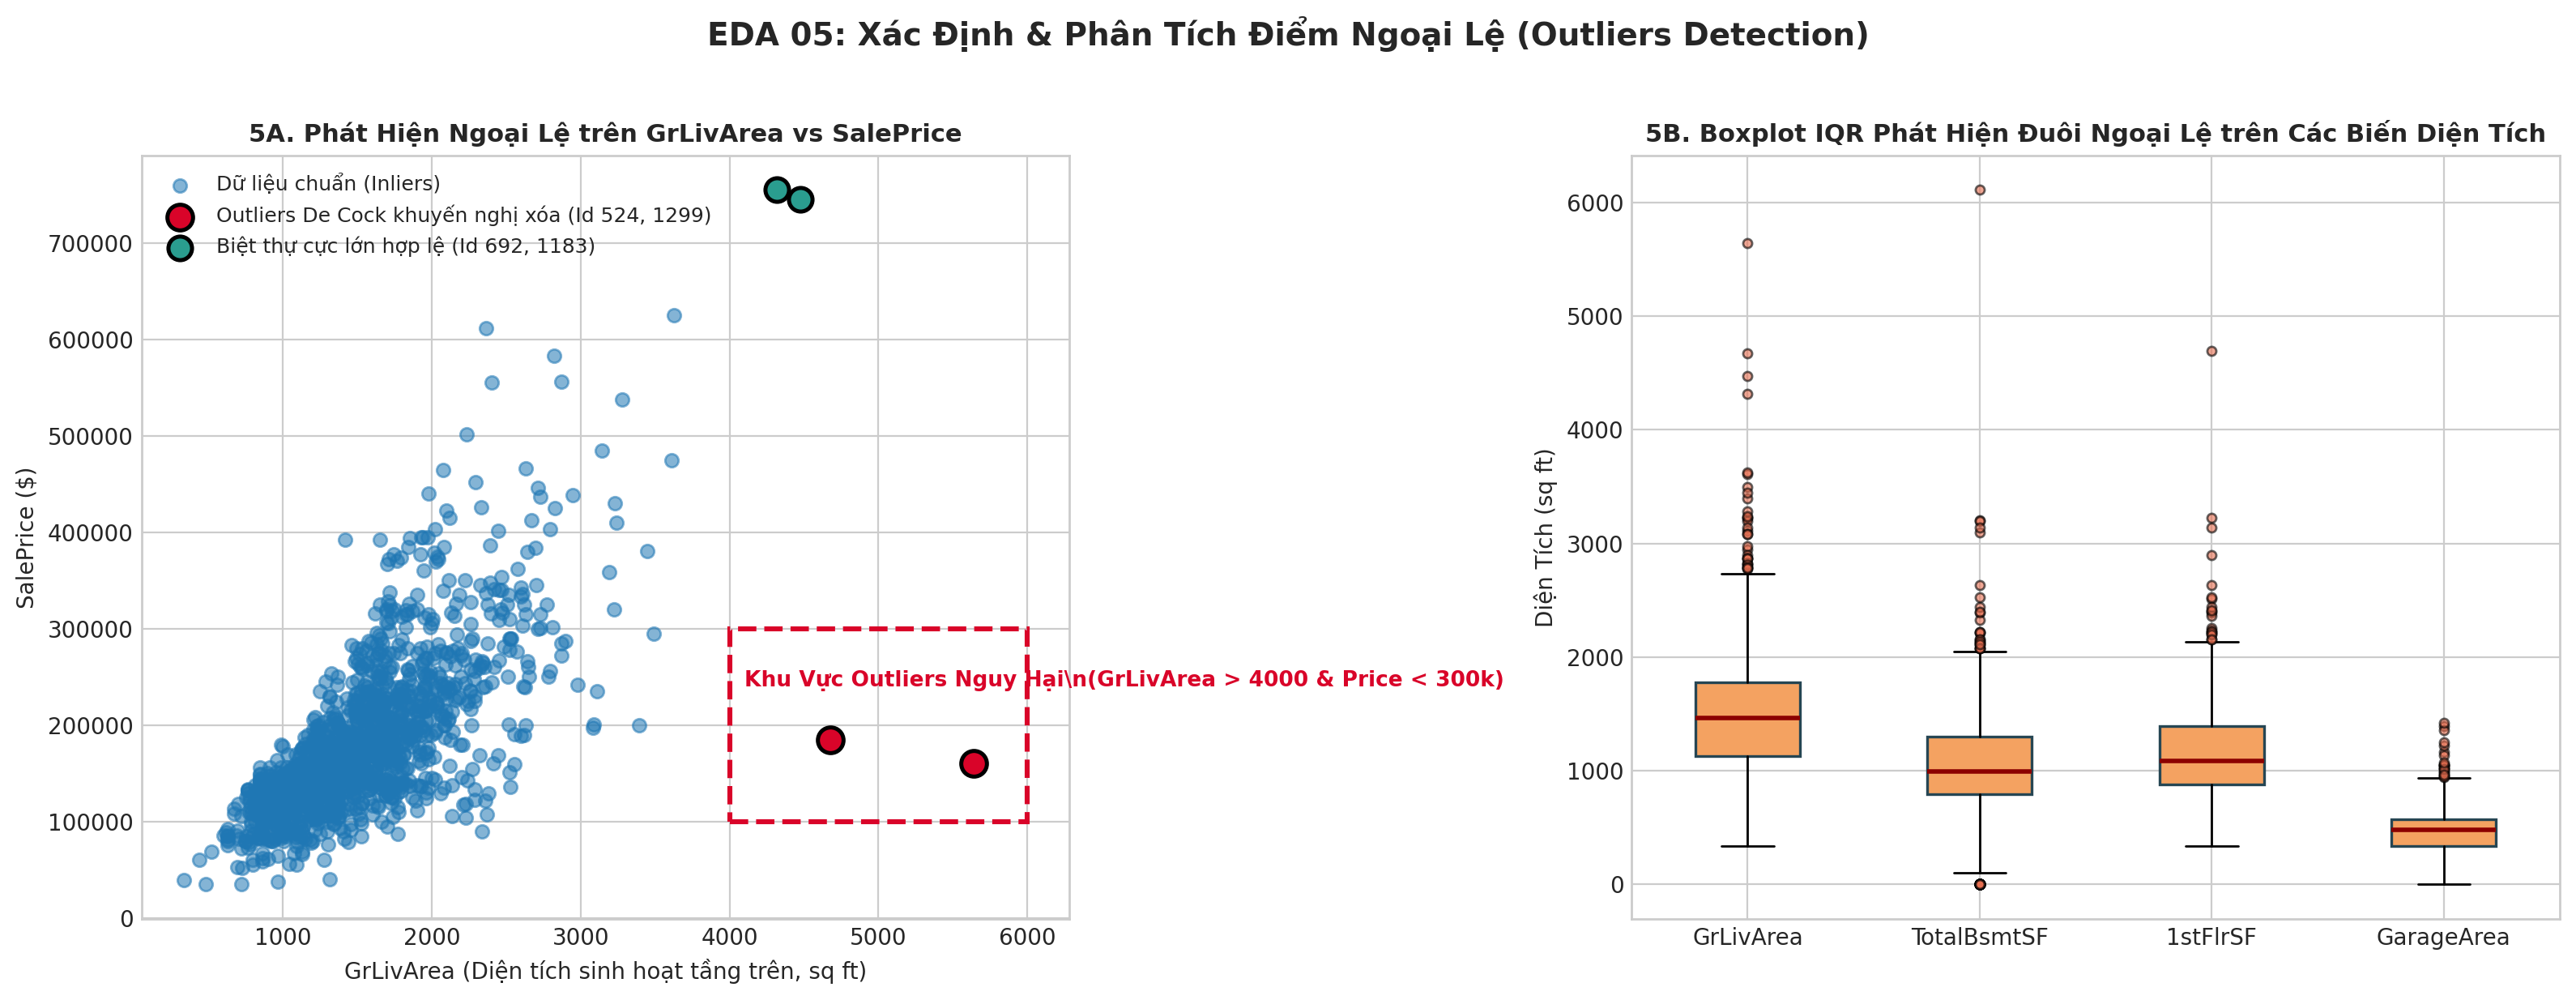

💾 Biểu đồ đã được lưu tại: plots\eda_05_outliers_detection.png


In [11]:
# Vẽ Biểu đồ 5: Trực quan hóa phát hiện điểm ngoại lệ
from matplotlib.patches import Rectangle

fig, axes = plt.subplots(1, 2, figsize=(16, 6), dpi=200)

# 5A: Scatter GrLivArea vs SalePrice khoanh vùng Outliers
axes[0].scatter(train[~decock_cond]['GrLivArea'], train[~decock_cond]['SalePrice'],
                color='#1f77b4', alpha=0.55, s=35, label='Dữ liệu chuẩn (Inliers)')
axes[0].scatter(decock_outliers['GrLivArea'], decock_outliers['SalePrice'],
                color='#d90429', s=130, edgecolors='black', lw=1.8, zorder=5, 
                label='Outliers De Cock khuyến nghị xóa (Id 524, 1299)')
axes[0].scatter(normal_large['GrLivArea'], normal_large['SalePrice'],
                color='#2a9d8f', s=110, edgecolors='black', lw=1.8, zorder=5, 
                label='Biệt thự cực lớn hợp lệ (Id 692, 1183)')

# Hộp khoanh vùng outlier
rect = Rectangle((4000, 100000), 2000, 200000, fill=False, edgecolor='#d90429', linestyle='--', lw=2.2)
axes[0].add_patch(rect)
axes[0].text(4100, 240000, 'Khu Vực Outliers Nguy Hại\\n(GrLivArea > 4000 & Price < 300k)',
             color='#d90429', fontweight='bold', fontsize=9.5)

axes[0].set_title('5A. Phát Hiện Ngoại Lệ trên GrLivArea vs SalePrice', fontweight='bold', fontsize=11)
axes[0].set_xlabel('GrLivArea (Diện tích sinh hoạt tầng trên, sq ft)', fontsize=10)
axes[0].set_ylabel('SalePrice ($)', fontsize=10)
axes[0].legend(loc='upper left', fontsize=9)

# 5B: Boxplot kiểm tra phân vị IQR trên 4 biến diện tích
norm_features = ['GrLivArea', 'TotalBsmtSF', '1stFlrSF', 'GarageArea']
scaled_data = [train[f].dropna().values for f in norm_features]
axes[1].boxplot(scaled_data, tick_labels=norm_features, patch_artist=True,
                boxprops=dict(facecolor='#f4a261', edgecolor='#264653', lw=1.2),
                medianprops=dict(color='darkred', lw=2),
                flierprops=dict(marker='o', markersize=4, markerfacecolor='#e76f51', alpha=0.6))
axes[1].set_title('5B. Boxplot IQR Phát Hiện Đuôi Ngoại Lệ trên Các Biến Diện Tích', fontweight='bold', fontsize=11)
axes[1].set_ylabel('Diện Tích (sq ft)', fontsize=10)

fig.suptitle('EDA 05: Xác Định & Phân Tích Điểm Ngoại Lệ (Outliers Detection)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()

plot5_path = os.path.join(PLOTS_DIR, 'eda_05_outliers_detection.png')
plt.savefig(plot5_path, bbox_inches='tight')
plt.show()
print(f"💾 Biểu đồ đã được lưu tại: {plot5_path}")

---
## 📋 6. Bảng Tổng Hợp Khuyến Nghị Tiền Xử Lý Dữ Liệu

Dựa trên các phát hiện chi tiết từ 5 khía cạnh EDA, dưới đây là **Checklist Tiền Xử Lý Dữ Liệu** phục vụ trực tiếp cho quá trình xây dựng mô hình Machine Learning:

| TT | Khía Cạnh Phát Hiện (EDA Finding) | Giải Pháp Tiền Xử Lý Cụ Thể (Preprocessing Strategy) |
|---|---|---|
| **1** | **Outliers nguy hại** (Id 524, 1299) có đòn bẩy cực lớn kéo lệch hồi quy | **Loại bỏ chính xác 2 mẫu này** khỏi tập huấn luyện trước khi fit model: `GrLivArea > 4000 & SalePrice < 300000`. Giữ lại Id 692, 1183. |
| **2** | **SalePrice lệch phải nặng** (Skew = 1.88, Kurt = 6.54) | **Áp dụng log-transform**: Huấn luyện mô hình trên $y = \ln(1 + \text{SalePrice})$, sau đó dùng hàm mũ $\exp(y) - 1$ để chuyển dự đoán về giá USD thực tế. |
| **3** | **Missing Cấu Trúc** (PoolQC, MiscFeature, Alley, Fence, Fireplace, Garage, Bsmt) | **Điền có ý nghĩa**: Điền `'None'` cho các cột định tính và `0` cho các cột diện tích/số lượng tương ứng (thay vì điền mean/mode). |
| **4** | **Missing Ngẫu Nhiên** (`LotFrontage` thiếu 17.7%) | **Impute theo phân vị nhóm**: Điền bằng **median theo từng khu phố (`Neighborhood`)** vì mặt tiền nhà phụ thuộc trực tiếp vào quy hoạch phân vùng. |
| **5** | **Mâu thuẫn dữ liệu** (`GarageYrBlt = 2207` ở Test set, Id 2593) | **Hiệu chỉnh logic**: Thay thế bằng năm xây dựng thực tế `YearBuilt = 2006`. |
| **6** | **Đa cộng tuyến nghiêm trọng** ($r > 0.75$ giữa GarageCars-GarageArea, YearBuilt-GarageYrBlt) | Cần chuẩn hóa dữ liệu (`StandardScaler`) kèm kỹ thuật điều chuẩn **L2/L1 (Ridge, ElasticNet)** hoặc tận dụng cơ chế chọn lọc nhánh ngẫu nhiên của các mô hình cây (**LightGBM, XGBoost, CatBoost, Random Forest**). |

---
🎉 **HOÀN TẤT BÁO CÁO PHÂN TÍCH KHÁM PHÁ DỮ LIỆU (EDA)**. Bạn có thể mở tệp `house_price_models.ipynb` để theo dõi các bước tiền xử lý và huấn luyện 6 mô hình Machine Learning!